# CS 3110/5110: Data Privacy
## In-Class Exercises, week of 9/8/2025

In [95]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv('https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv')

## Question 1

Write a *counting query* to determine whether or not Karrie Trusslove's age is 39.

In [96]:
def karrie_query():
    return adult[(adult['Name']=='Karrie Trusslove') & (adult['Age']==39)].shape[0]

In [97]:
# TEST CASE 

assert karrie_query() == 1

## Question 2

Add Laplace noise to the counting query you wrote in the last question to ensure differential privacy for $\epsilon = 1.0$.

In [98]:
sensitivity = 1
epsilon = 1.0

def dp_karrie_query():
    return karrie_query() + np.random.laplace(loc=0, scale=sensitivity/epsilon)

In [99]:
# TEST CASE 

q2_runs = [dp_karrie_query() for _ in range(100)]
noise_runs = [np.random.laplace(loc=1, scale=1/epsilon) for _ in range(100)]

assert stats.wasserstein_distance(q2_runs, noise_runs) < 1

## Question 3

In 2-4 sentences, describe how `dp_karrie_query` protects Karrie's privacy.

1) karrie_query is an aggregation result (count), but it is over a group of one person, so it doesn’t really help protect Karrie’s privacy.
2) The noise adds uncertainty about whether the original result was 0 or 1, making it difficult for an adversary observing a single output to tell which it was.
3) If we change epsilon, we change the amount of uncertainty we add, allowing us to trade off between utility and privacy.
4) In this case, if we do a good job on privacy, there is basically no utility (this is a feature, not a bug).

## Question 4

Implement a function to construct an *empirical distribution* over random samples from the Laplace distribution with location 0 and scale `scale`. Use 1000 samples.

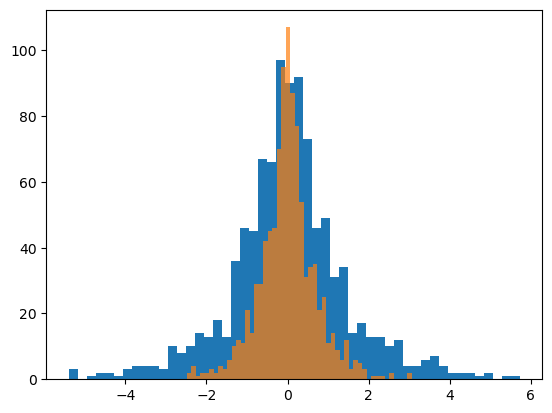

In [100]:
def empirical_dist_lap(scale):
    return [np.random.laplace(loc=0, scale=scale) for _ in range(1000)]

epsilon1 = 1.0
epsilon2 = 2.0

plt.hist(empirical_dist_lap(1/epsilon1), bins=50);
plt.hist(empirical_dist_lap(1/epsilon2), bins=50, alpha=.7);

In [101]:
# PLACEHOLDER for test cases


## Question 5

Consider the program below.

In [102]:
counting_query = lambda: 1

result_1 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)
result_2 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon2)
result_3 = counting_query() + np.random.laplace(loc=0, scale=1/epsilon1)

print(result_1, result_2, result_3)

-0.27800566758685874 2.5432689696988025 0.8227366293017513


Write a function `total_epsilon` that returns the total privacy cost for this program.

In [103]:
def total_epsilon():
    return epsilon1 + epsilon2 + epsilon1

In [104]:
total_epsilon()


4.0

In [105]:
# Placeholder for test case
